In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# 1. Load dataset
df = pd.read_csv("dataset - 1.csv")

In [3]:
# Display basic dataset info
print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction Date    6000 non-null   int64  
 1   Transaction Month   6000 non-null   int64  
 2   Transaction Year    6000 non-null   int64  
 3   Time                6000 non-null   int64  
 4   UPI Number          6000 non-null   int64  
 5   UPI ID              6000 non-null   float64
 6   Transaction Amount  6000 non-null   float64
 7   Zip Code            6000 non-null   int64  
 8   Fraud               6000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 422.0 KB
None

First few rows:
   Transaction Date  Transaction Month  Transaction Year  Time  UPI Number  \
0                 7                  9              2022    12  2466774878   
1                20                  6              2021    18  8814420348   
2                29              

In [4]:
# Step 2: Handle missing values
df.dropna(inplace=True)

In [5]:
# Step 3: Feature Engineering
# Assuming columns: 'amount', 'timestamp', 'location', 'device_id', 'is_fraud'
# Check if 'Transaction Date' is the actual timestamp column
if 'Transaction Date' in df.columns:
    df['hour'] = pd.to_datetime(df['Transaction Date']).dt.hour  # Extract hour from timestamp
    df['day'] = pd.to_datetime(df['Transaction Date']).dt.day    # Extract day from timestamp
else:
    print("Error: 'Transaction Date' column not found. Please check the column name.")

In [6]:
# Drop non-numeric and unnecessary columns
# Check if columns exist before dropping to avoid KeyError
columns_to_drop = ['timestamp', 'location', 'device_id']
existing_columns = [col for col in columns_to_drop if col in df.columns]

if existing_columns:
    df.drop(columns=existing_columns, inplace=True)
else:
    print("Columns to drop not found in DataFrame.")

Columns to drop not found in DataFrame.


In [7]:
# 5. Define Features and Target
X = df.drop(columns=["Fraud"])  # Replace "isFraud" with your actual target column
y = df["Fraud"]

In [8]:
# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [9]:
# Convert back to DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled["target"] = y_resampled

In [10]:
# Save synthetic dataset
df_resampled.to_csv("synthetic_dataset.csv", index=False)

In [11]:
from google.colab import files
files.download("synthetic_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("synthetic_dataset.csv")  # Use the path of your dataset

# Define Features (X) and Target (y)
X = df.drop(columns=["target"])  # Replace "isFraud" with your actual target column
y = df["target"]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print shape to verify
print("Training set size:", X_train.shape, y_train.shape)
print("Testing set size:", X_test.shape, y_test.shape)

Training set size: (8057, 10) (8057,)
Testing set size: (2015, 10) (2015,)


In [13]:
# Step 8: Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [14]:
# Step 9: Predictions
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import classification_report, accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Generate classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert values to percentages
for label, metrics in report.items():
    if isinstance(metrics, dict):  # Ignore overall accuracy
        for metric in metrics:
            metrics[metric] = round(metrics[metric] * 100, 2)  # Convert to percentage

# Print accuracy and classification report
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report (in %):")
for label, metrics in report.items():
    if isinstance(metrics, dict):
        print(f"\nClass {label}:")
        print(f"  Precision: {metrics['precision']}%")
        print(f"  Recall: {metrics['recall']}%")
        print(f"  F1-Score: {metrics['f1-score']}%")
        print(f"  Support: {int(metrics['support'])}")  # Support remains an integer

Model Accuracy: 78.76%

Classification Report (in %):

Class 0:
  Precision: 80.59%
  Recall: 75.79%
  F1-Score: 78.12%
  Support: 100800

Class 1:
  Precision: 77.13%
  Recall: 81.73%
  F1-Score: 79.36%
  Support: 100700

Class macro avg:
  Precision: 78.86%
  Recall: 78.76%
  F1-Score: 78.74%
  Support: 201500

Class weighted avg:
  Precision: 78.86%
  Recall: 78.76%
  F1-Score: 78.74%
  Support: 201500


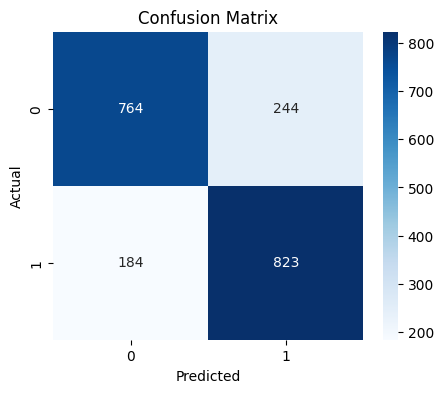

In [20]:
# Step 10: Confusion Matrix
import matplotlib.pyplot as plt  # Import the pyplot module
import seaborn as sns  # Import seaborn for heatmap
from sklearn.metrics import confusion_matrix # import for confusion_matrix

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [21]:
y_pred = model.predict(X_test)

In [22]:
accuracy_score(y_test, y_pred)

0.7875930521091812

In [23]:
print("Features used for training:", X.columns.tolist())



Features used for training: ['Transaction Date', 'Transaction Month', 'Transaction Year', 'Time', 'UPI Number', 'UPI ID', 'Transaction Amount', 'Zip Code', 'hour', 'day']


In [26]:
# Ensure the new transaction has all required features
# Get the list of columns from the training data (X)
columns = X.columns.tolist()

# Create the new transaction DataFrame with matching columns and data
new_transaction = pd.DataFrame([[
    14150,  # Example transaction amount
    4,    # time of transaction
    0,    # Day of transaction
    26,     # Example: Transaction Date
    1,     # Example: Month
    2023,  # Example: Year
    29800,     # zip code
    0,     # Example value for an additional column (replace with actual value)
    0,     # Example value for an additional column (replace with actual value)
    0      # Example value for an additional column (replace with actual value)


]], columns=columns)  # Ensure column names match training data

# Step 3: Standardize the new transaction using the same scaler
# Before standardizing, make sure the scaler is fitted using the training data (X)
# Example: scaler = StandardScaler().fit(X)
# new_transaction = scaler.transform(new_transaction)

# Step 4: Predict fraud
fraud_prediction = model.predict(new_transaction)

# Step 5: Print the result
print("Fraudulent Transaction" if fraud_prediction[0] == 1 else "Legitimate Transaction")

Fraudulent Transaction
